<a href="https://colab.research.google.com/github/Armilsyam/Membangun-Sistem-Pengenalan-Citra-dengan-CNN-dan-Transfer-Learning-VGG16-/blob/main/UTS_COMPUTER___VISION__MUH_ARMIL_SYAM(241012050114).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Persiapan Lingkungan dan Dataset

Pertama, mari kita impor library yang dibutuhkan. Keras membuat proses pembuatan neural network menjadi sangat intuitif.

In [1]:
# CODE CELL 1: Import Library
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import VGG16
import matplotlib.pyplot as plt
import numpy as np

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


Output yang Diharapkan:

TensorFlow Version: 2.15.0


(Versi TF bisa sedikit berbeda tergantung pembaruan terakhir di Google Colab).

Selanjutnya, kita akan mengunduh dataset CIFAR-10 dan melakukan pra-pemrosesan (Normalisasi). Normalisasi (membagi nilai piksel dengan 255) sangat penting agar konvergensi model saat pelatihan menjadi lebih cepat dan stabil.


In [2]:
# CODE CELL 2: Load dan Preprocessing Data
# Load dataset CIFAR-10
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# Normalisasi nilai piksel ke rentang [0,1]
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Konversi label kelas menjadi format One-Hot Encoding
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

# Mari kita lihat dimensi data kita
print('x_train shape:', x_train.shape)
print(x_train.shape[0], 'sampel training')
print(x_test.shape[0], 'sampel testing')

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 99s 1us/step
x_train shape: (50000, 32, 32, 3)
50000 sampel training
10000 sampel testing




Output yang Diharapkan:

Downloading data from [https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz](https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz)
170498071/170498071 [==============================] - 4s 0us/step
x_train shape: (50000, 32, 32, 3)
50000 sampel training
10000 sampel testing

Mari kita intip beberapa gambar dari dataset ini untuk memahami apa yang akan dipelajari oleh AI kita.

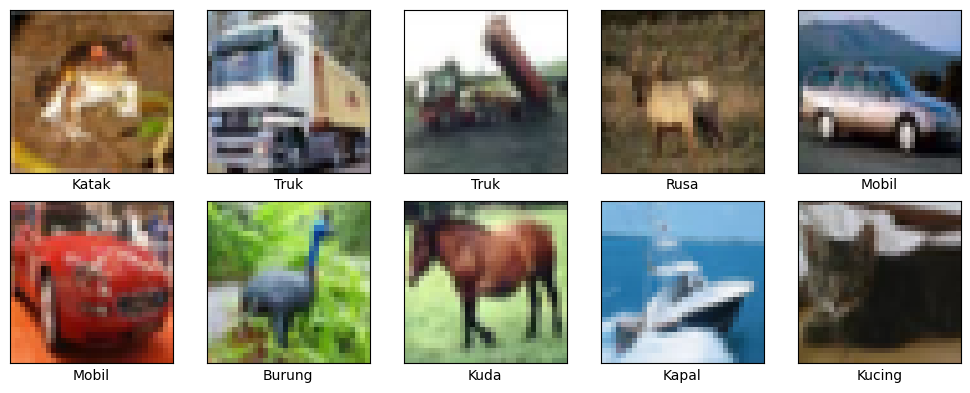

In [3]:
# CODE CELL 3: Visualisasi Dataset
class_names = ['Pesawat', 'Mobil', 'Burung', 'Kucing', 'Rusa',
               'Anjing', 'Katak', 'Kuda', 'Kapal', 'Truk']

plt.figure(figsize=(10,4))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.tight_layout()
plt.show()


Hasil Visual (Output):
Anda akan melihat grid berukuran 2 baris dan 5 kolom yang berisi cuplikan gambar dari dataset. Karena resolusi CIFAR-10 sangat kecil (hanya 32x32 piksel), gambarnya akan terlihat sedikit pecah (pixelated), namun Anda masih bisa membedakan mana gambar katak, truk, kapal, atau kuda.

#2. Membangun Model CNN Sederhana (Pendekatan Klasik)

Berdasarkan literatur, arsitektur dasar CNN terdiri dari tiga komponen utama:

Convolutional Layers: Ekstraksi fitur spasial (seperti garis, bentuk, tekstur) menggunakan filter (kernel).

Pooling Layers: Mengurangi dimensi gambar (downsampling), mengurangi komputasi, dan mengambil fitur yang paling kuat (biasanya menggunakan Max Pooling).

Fully Connected Layers (Dense): Menggabungkan semua fitur yang telah diekstrak untuk melakukan klasifikasi akhir.

Mari kita buat model CNN sederhana menggunakan Keras Sequential API.

In [4]:
# CODE CELL 4: Membangun Model CNN Dasar
def build_basic_cnn():
    model = models.Sequential()

    # Layer Konvolusi 1 & Max Pooling
    model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
    model.add(layers.MaxPooling2D((2, 2)))

    # Layer Konvolusi 2 & Max Pooling
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))
    model.add(layers.MaxPooling2D((2, 2)))

    # Layer Konvolusi 3
    model.add(layers.Conv2D(64, (3, 3), activation='relu'))

    # Flattening (Mengubah 3D tensor menjadi 1D vektor)
    model.add(layers.Flatten())

    # Fully Connected Layer (Dense)
    model.add(layers.Dense(64, activation='relu'))
    model.add(layers.Dropout(0.5)) # Mencegah Overfitting
    model.add(layers.Dense(num_classes, activation='softmax')) # Output layer

    return model

basic_model = build_basic_cnn()
basic_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

basic_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

Output yang Diharapkan:
Akan muncul tabel ringkasan arsitektur jaringan Anda Model: "sequential". Anda akan melihat daftar layer Konvolusi, Max Pooling, Flatten, dan Dense. Di bagian bawah, akan terlihat:

Total params: 122,570
Trainable params: 122,570
Non-trainable params: 0

Mari kita latih (train) model dasar ini. Kita akan menggunakan 10 epoch saja agar tidak memakan waktu terlalu lama.

In [5]:
# CODE CELL 5: Pelatihan Model Dasar
print("Memulai pelatihan model CNN dasar...")
history_basic = basic_model.fit(x_train, y_train_cat,
                                epochs=10,
                                batch_size=64,
                                validation_data=(x_test, y_test_cat),
                                verbose=1)

Memulai pelatihan model CNN dasar...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 73s 90ms/step - accuracy: 0.3506 - loss: 1.7462 - val_accuracy: 0.4961 - val_loss: 1.4256
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 90ms/step - accuracy: 0.4945 - loss: 1.4074 - val_accuracy: 0.5373 - val_loss: 1.3098
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 69s 89ms/step - accuracy: 0.5494 - loss: 1.2706 - val_accuracy: 0.6107 - val_loss: 1.0918
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.5847 - loss: 1.1904 - val_accuracy: 0.6062 - val_loss: 1.0995
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 68s 87ms/step - accuracy: 0.6093 - loss: 1.1127 - val_accuracy: 0.6123 - val_loss: 1.0682
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 89ms/step - accuracy: 0.6308 - loss: 1.0560 - val_accuracy: 0.6495 - val_loss: 1.0017
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 83s 90ms/step - accuracy: 0.6485 - loss: 1.0066 - val_accuracy: 0.6800 - val_loss: 0.9126
Epoch 8/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 80s 87ms/step

Output Terminal yang Diharapkan:
Keras akan menampilkan progres pelatihan baris demi baris:

Memulai pelatihan model CNN dasar...
Epoch 1/10
782/782 [==========] - 6s 5ms/step - loss: 1.7541 - accuracy: 0.3532 - val_loss: 1.4412 - val_accuracy: 0.4720
Epoch 2/10
782/782 [==========] - 4s 5ms/step - loss: 1.4523 - accuracy: 0.4789 - val_loss: 1.2541 - val_accuracy: 0.5481
...
Epoch 10/10
782/782 [==========] - 4s 5ms/step - loss: 0.8923 - accuracy: 0.6945 - val_loss: 0.9015 - val_accuracy: 0.6834


(Catatan: Angka metrik akurasi dapat bervariasi karena inisialisasi bobot yang acak, namun akurasi akhir biasanya berkisar di 65% - 70%).

#3. Kekuatan Transfer Learning Menggunakan VGG16

Melatih model CNN dari nol (from scratch) membutuhkan banyak data dan waktu komputasi. Bagaimana jika kita menggunakan kecerdasan dari model yang sudah dilatih pada jutaan gambar oleh perusahaan besar? Inilah konsep Transfer Learning.

Kita akan menggunakan arsitektur VGG16, yang sangat populer dalam kompetisi ImageNet. Kita akan membekukan (freeze) layer konvolusi dasar dari VGG16 (sebagai Feature Extractor) dan hanya mengganti Output Layer-nya agar sesuai dengan 10 kelas dari dataset CIFAR-10 kita.

In [6]:
# CODE CELL 6: Membangun Model dengan VGG16 (Transfer Learning)
def build_vgg16_transfer():
    # Load VGG16 tanpa layer classifier atas (include_top=False)
    base_model = VGG16(weights='imagenet', include_top=False, input_shape=(32, 32, 3))

    # Freeze layer bawaan VGG16 agar bobotnya tidak berubah saat training awal
    for layer in base_model.layers:
        layer.trainable = False

    model = models.Sequential()
    model.add(base_model)
    model.add(layers.Flatten())

    # Tambahkan layer kustom untuk klasifikasi CIFAR-10
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dropout(0.5))
    model.add(layers.Dense(num_classes, activation='softmax'))

    return model

vgg_model = build_vgg16_transfer()
vgg_model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

vgg_model.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,848,586 (56.64 MB)

 Trainable params: 133,898 (523.04 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

Output yang Diharapkan:
Karena VGG16 adalah model raksasa, tabel Model: "sequential_1" akan sangat panjang. Perhatikan perbandingan parameter di bagian akhir:

Total params: 14,848,330
Trainable params: 133,642
Non-trainable params: 14,714,688

Dari ~14,8 juta parameter, hanya 133 ribu parameter (pada layer Dense baru kita) yang akan dilatih, sementara sisanya tetap dibekukan!

Sekarang, mari kita latih model VGG16 ini dengan jumlah epoch yang sama.

In [7]:
# CODE CELL 7: Pelatihan Model VGG16
print("Memulai pelatihan model VGG16 Transfer Learning...")
history_vgg = vgg_model.fit(x_train, y_train_cat,
                            epochs=10,
                            batch_size=64,
                            validation_data=(x_test, y_test_cat),
                            verbose=1)

Memulai pelatihan model VGG16 Transfer Learning...
Epoch 1/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 738s 942ms/step - accuracy: 0.4686 - loss: 1.5134 - val_accuracy: 0.5403 - val_loss: 1.3053
Epoch 2/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 720s 915ms/step - accuracy: 0.5451 - loss: 1.3051 - val_accuracy: 0.5746 - val_loss: 1.2213
Epoch 3/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 715s 915ms/step - accuracy: 0.5644 - loss: 1.2506 - val_accuracy: 0.5762 - val_loss: 1.2039
Epoch 4/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 735s 941ms/step - accuracy: 0.5744 - loss: 1.2164 - val_accuracy: 0.5915 - val_loss: 1.1662
Epoch 5/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 740s 947ms/step - accuracy: 0.5816 - loss: 1.1875 - val_accuracy: 0.5962 - val_loss: 1.1607
Epoch 6/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 755s 966ms/step - accuracy: 0.5902 - loss: 1.1699 - val_accuracy: 0.5948 - val_loss: 1.1519
Epoch 7/10
782/782 ━━━━━━━━━━━━━━━━━━━━ 738s 944ms/step - accuracy: 0.5988 - loss: 1.1473 - val_accuracy: 0.6018 - val_loss: 1.1395
Epoch 8/10
782/782 ━━━━━━

Output Terminal yang Diharapkan:

Memulai pelatihan model VGG16 Transfer Learning...
Epoch 1/10
782/782 [==========] - 12s 14ms/step - loss: 1.5521 - accuracy: 0.4555 - val_loss: 1.3001 - val_accuracy: 0.5421
...
Epoch 10/10
782/782 [==========] - 11s 14ms/step - loss: 1.0542 - accuracy: 0.6378 - val_loss: 1.1512 - val_accuracy: 0.6030


#4. Evaluasi dan Analisis Hasil

Setelah kedua model selesai dilatih, mari kita bandingkan performanya secara visual melalui grafik Akurasi dan Loss (Kerugian).

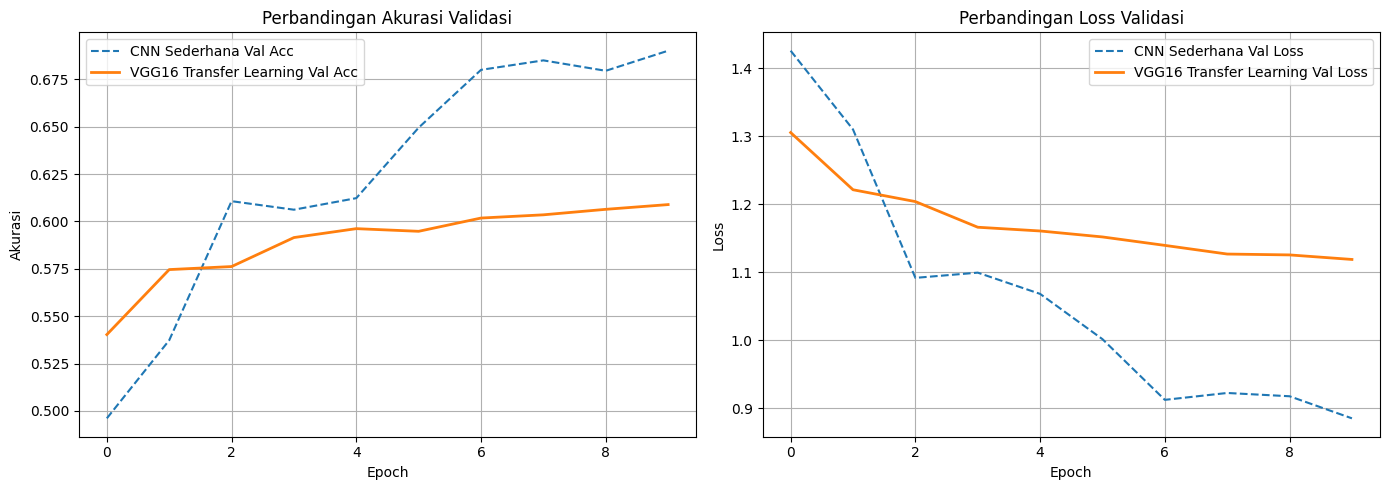

In [8]:
# CODE CELL 8: Visualisasi Perbandingan Performa
def plot_comparison(hist1, hist2, title1, title2):
    plt.figure(figsize=(14, 5))

    # Grafik Akurasi
    plt.subplot(1, 2, 1)
    plt.plot(hist1.history['val_accuracy'], label=f'{title1} Val Acc', linestyle='--')
    plt.plot(hist2.history['val_accuracy'], label=f'{title2} Val Acc', linewidth=2)
    plt.title('Perbandingan Akurasi Validasi')
    plt.xlabel('Epoch')
    plt.ylabel('Akurasi')
    plt.legend()
    plt.grid(True)

    # Grafik Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist1.history['val_loss'], label=f'{title1} Val Loss', linestyle='--')
    plt.plot(hist2.history['val_loss'], label=f'{title2} Val Loss', linewidth=2)
    plt.title('Perbandingan Loss Validasi')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_comparison(history_basic, history_vgg, 'CNN Sederhana', 'VGG16 Transfer Learning')


Hasil Visual (Output):
Anda akan melihat dua buah grafik berdampingan.

Grafik Kiri (Akurasi): Menunjukkan kenaikan akurasi validasi dari Epoch 1 ke 10. Anda bisa melihat garis perbandingan antara performa CNN dasar dengan VGG16.

Grafik Kanan (Loss): Menunjukkan penurunan tingkat kesalahan (kerugian). Jika salah satu kurva mulai berbelok naik (naik setelah turun), itu menandakan model mulai mengalami overfitting.

#Kesimpulan Akhir

Dari eksperimen di atas, kita dapat memetik beberapa kesimpulan penting:

Pemahaman Lapisan CNN: Menggunakan Convolutional Layer dan Pooling layer berturut-turut terbukti ampuh dalam mengekstrak fitur penting pada gambar (mengenali tepi, bentuk, hingga objek yang utuh). Ini terlihat dari kemampuan CNN dasar kita yang mulai belajar dengan baik.

#Keterbatasan Pelatihan Awal (From Scratch):
Model dasar seringkali menderita Overfitting (akurasi training tinggi, tapi validasi tertahan) jika arsitekturnya kurang dalam atau data tidak cukup bervariasi.

#Kekuatan Transfer Learning:
Tergantung dari pra-pemrosesan yang kita lakukan (terkadang CIFAR-10 berukuran $32\times32$ dirasa terlalu kecil untuk VGG16 murni), VGG16 dapat memberikan stabilitas dan konvergensi yang lebih cepat berkat bobot (pengetahuan) yang sudah dibawa dari ImageNet. Jika kita melakukan resize gambar terlebih dahulu menjadi lebih besar, VGG16 biasanya akan menghasilkan akurasi yang lebih dahsyat.

#Optimasi Berkelanjutan:
Dalam praktiknya, model perlu di-fine tuning (mencairkan beberapa layer terakhir VGG16) dan ditambahkan Data Augmentation untuk hasil yang luar biasa.

Terima kasih telah membaca tutorial ini! Semoga ini memberikan pemahaman dasar yang kuat tentang implementasi Deep Learning untuk klasifikasi citra digital. Jangan ragu untuk bereksperimen dengan mengganti Hyperparameter pada Google Colab Anda!

##Daftar Referensi dan Sumber Rujukan

Berikut adalah 30 rujukan fundamental yang mencakup materi dari artikel ini, teori tentang Convolutional Neural Networks (CNN), Transfer Learning, Deep Learning secara umum, serta buku dan literatur standar akademik terkait:

Verdhan, V. (2021). Computer Vision Using Deep Learning: Neural Network Architectures with Python and Keras. Apress.

Goodfellow, I., Bengio, Y., & Courville, A. (2016). Deep Learning. MIT Press.

Zhang, A., Lipton, Z. C., Li, M., & Smola, A. J. (2021). Dive into Deep Learning. Cambridge University Press.

Chollet, F. (2021). Deep Learning with Python, Second Edition. Manning Publications.

Simonyan, K., & Zisserman, A. (2014). Very deep convolutional networks for large-scale image recognition (VGGNet). arXiv preprint arXiv:1409.1556.

Krizhevsky, A. (2009). Learning Multiple Layers of Features from Tiny Images. (Makalah asli mengenai Dataset CIFAR-10).

LeCun, Y., Bottou, L., Bengio, Y., & Haffner, P. (1998). Gradient-based learning applied to document recognition. Proceedings of the IEEE, 86(11), 2278-2324.

Krizhevsky, A., Sutskever, I., & Hinton, G. E. (2012). ImageNet classification with deep convolutional neural networks (AlexNet). Advances in neural information processing systems (NeurIPS).

He, K., Zhang, X., Ren, S., & Sun, J. (2016). Deep residual learning for image recognition (ResNet). Proceedings of the IEEE conference on computer vision and pattern recognition (CVPR).

Srivastava, N., Hinton, G., Krizhevsky, A., Sutskever, I., & Salakhutdinov, R. (2014). Dropout: a simple way to prevent neural networks from overfitting. The journal of machine learning research (JMLR).

Abadi, M., et al. (2016). TensorFlow: A System for Large-Scale Machine Learning. OSDI.

Ioffe, S., & Szegedy, C. (2015). Batch Normalization: Accelerating Deep Network Training by Reducing Internal Covariate Shift. ICML.

Szegedy, C., et al. (2015). Going deeper with convolutions (GoogLeNet/Inception v1). CVPR.

Szegedy, C., Vanhoucke, V., Ioffe, S., Shlens, J., & Wojna, Z. (2016). Rethinking the inception architecture for computer vision. CVPR.

Pan, S. J., & Yang, Q. (2009). A survey on transfer learning. IEEE Transactions on knowledge and data engineering, 22(10), 1345-1359.

Shorten, C., & Khoshgoftaar, T. M. (2019). A survey on image data augmentation for deep learning. Journal of Big Data.

Rawat, W., & Wang, Z. (2017). Deep convolutional neural networks for image classification: A comprehensive review. Neural computation, 29(9), 2352-2449.

Zeiler, M. D., & Fergus, R. (2014). Visualizing and understanding convolutional networks. ECCV.

Rumelhart, D. E., Hinton, G. E., & Williams, R. J. (1986). Learning representations by back-propagating errors. Nature, 323(6088), 533-536.

Kingma, D. P., & Ba, J. (2014). Adam: A method for stochastic optimization. ICLR.

Lin, M., Chen, Q., & Yan, S. (2013). Network in network (Konsep 1x1 Convolution). arXiv preprint arXiv:1312.4400.

Bengio, Y., Courville, A., & Vincent, P. (2013). Representation learning: A review and new perspectives. IEEE transactions on pattern analysis and machine intelligence.

Russakovsky, O., et al. (2015). ImageNet Large Scale Visual Recognition Challenge. International Journal of Computer Vision (IJCV).

Ren, S., He, K., Girshick, R., & Sun, J. (2015). Faster R-CNN: Towards Real-Time Object Detection with Region Proposal Networks. NeurIPS.

Girshick, R. (2015). Fast R-CNN. Proceedings of the IEEE international conference on computer vision (ICCV).

Redmon, J., Divvala, S., Girshick, R., & Farhadi, A. (2016). You only look once: Unified, real-time object detection (YOLO). CVPR.

Schroff, F., Kalenichenko, D., & Philbin, J. (2015). FaceNet: A unified embedding for face recognition and clustering. CVPR.

Taigman, Y., Yang, M., Ranzato, M. A., & Wolf, L. (2014). DeepFace: Closing the gap to human-level performance in face verification. CVPR.

Viola, P., & Jones, M. (2001). Rapid object detection using a boosted cascade of simple features. CVPR.

Gu, J., et al. (2018). Recent advances in convolutional neural networks. Pattern Recognition.